# Homework Five, Part 2
## GSE 544 — Spring 2026
### A Copula/NCO Horse Race Under Realistic Constraints

**Three portfolios:** NCO (A) · All-at-once (B) · 1/N benchmark  
**Two regimes:** log utility γ=1 (full Kelly) · CRRA γ=3  
**Constraints:** long-only (w_j ≥ 0) · no-borrowing (Σw_j ≤ 1)  
**Data:** 2000-day training set · 500-day held-out test · `copula_model.pkl` from class repo


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pickle, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 9})

# ── Constants matching the lecture notebook exactly ──────────────────────────
RNG_SEED = 778
N_MC     = 500_000
EPS      = 1e-9
K        = 5       # number of clusters


---
## Data & Model Loading

In [2]:
# Load returns — stock_1 is the index column
raw     = pd.read_csv("vmls_portfolio_returns.csv", index_col=0)
stock1  = raw.index.values.astype(float).reshape(-1, 1)
returns = np.hstack([stock1, raw.values])   # (2500, 20)

R       = returns[:2000, :19]               # training: 2000 × 19 risky
R_test  = returns[2000:, :19]               # test:      500 × 19 risky
rf_col  = returns[:, 19]
rf_bar  = rf_col[:2000].mean()
T_test  = R_test.shape[0]
p       = 19
asset_names = [f"stock {j+1}" for j in range(p)]

print(f"Training set  R : {R.shape}")
print(f"Test set R_test : {R_test.shape}")
print(f"Risk-free mean  : {rf_bar:.6f}/day  ({rf_bar*250:.4%}/year)")

# Load the fitted copula model from the class repo
with open("copula_model.pkl", "rb") as fh:
    M = pickle.load(fh)
marginals_all = M["marginals"]   # 19 fitted (df, loc, scale)
chol_all      = M["chol_P"]     # Cholesky of 19×19 copula correlation
cap_all       = M["cap"]        # per-asset 2× max|train| clip
print("\n" + M["note"])


Training set  R : (2000, 19)
Test set R_test : (500, 19)
Risk-free mean  : 0.000040/day  (1.0000%/year)

Fitted on training set (first 2000 returns, 19 risky assets) by 3_copula_model_fitting.ipynb


---
## Helpers: Simulation, Clustering, Optimizer

In [3]:
# ── Simulation helpers (exact lecture code) ──────────────────────────────────
def _fit_marginals_and_corr(Mtx):
    k   = Mtx.shape[1]
    mar = [stats.t.fit(Mtx[:, j]) for j in range(k)]
    U   = np.clip(np.column_stack([stats.t.cdf(Mtx[:, j], *mar[j]) for j in range(k)]),
                  1e-6, 1-1e-6)
    Z   = stats.norm.ppf(U)
    Pc  = np.atleast_2d(np.corrcoef(Z, rowvar=False)) if k > 1 else np.array([[1.]])
    ev, V = np.linalg.eigh(Pc)
    Pc  = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d   = np.sqrt(np.diag(Pc)); Pc = Pc / np.outer(d, d)
    return mar, np.linalg.cholesky(Pc)

def fit_gaussian_copula(Mtx):
    mar, L = _fit_marginals_and_corr(Mtx)
    cap    = 2.0 * np.max(np.abs(Mtx), axis=0)
    return dict(mar=mar, L=L, cap=cap, k=Mtx.shape[1])

def simulate(model, n, seed):
    """Draw n correlated observations from the fitted Gaussian copula model."""
    k  = model["k"]
    g  = np.random.default_rng(seed)
    Zs = g.standard_normal((n, k)) @ model["L"].T
    Us = np.clip(stats.norm.cdf(Zs), 1e-9, 1-1e-9)
    sim = np.column_stack([stats.t.ppf(Us[:, j], *model["mar"][j]) for j in range(k)])
    return np.clip(sim, -model["cap"], model["cap"])


In [4]:
# ── Clustering (exact lecture code) ─────────────────────────────────────────
def codist(S):
    """MLDP correlation-distance matrix D_ij = sqrt(0.5*(1 - rho_ij))."""
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(0.5 * (1.0 - C))

def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    """k-means from scratch (textbook Ch. 4 Lloyd's algorithm)."""
    g = np.random.default_rng(seed)
    N, d = len(x), len(x[0])
    distances  = np.zeros(N)
    assignment = g.integers(1, k+1, size=N)
    reps = [np.zeros(d) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters+1):
        for j in range(1, k+1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j-1] = np.mean([x[i] for i in grp], axis=0)
        for i in range(N):
            dd = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i] = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances)**2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment

D_mat  = codist(R)
labels = kmeans_([D_mat[:, i] for i in range(p)], K, seed=RNG_SEED)
cluster_sizes = [int((labels == c).sum()) for c in range(1, K+1)]
print("Cluster labels (1-indexed):", labels)
print("Cluster sizes:", cluster_sizes)
for c in range(1, K+1):
    print(f"  Cluster {c}: stocks {list(np.where(labels==c)[0]+1)}")


Cluster labels (1-indexed): [5 2 3 1 3 2 4 2 4 1 4 1 1 3 4 4 3 5 5]
Cluster sizes: [4, 3, 4, 5, 3]
  Cluster 1: stocks [np.int64(4), np.int64(10), np.int64(12), np.int64(13)]
  Cluster 2: stocks [np.int64(2), np.int64(6), np.int64(8)]
  Cluster 3: stocks [np.int64(3), np.int64(5), np.int64(14), np.int64(17)]
  Cluster 4: stocks [np.int64(7), np.int64(9), np.int64(11), np.int64(15), np.int64(16)]
  Cluster 5: stocks [np.int64(1), np.int64(18), np.int64(19)]


In [5]:
# ── Constrained CRRA optimizer ───────────────────────────────────────────────
def gross_growth(w, Rm):
    """Daily gross growth: risk-free earns the residual budget."""
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w

def crra_opt(Rm, gamma):
    """
    Maximize E[u_gamma(1 + g_t(w))] subject to:
        w_j >= 0  (no shorting)
        sum(w) <= 1  (no borrowing)
    gamma=1  -> log utility (full Kelly)
    gamma!=1 -> CRRA: E[(W^(1-gamma) - 1) / (1-gamma)]
    """
    n = Rm.shape[1]
    def neg_eu(w):
        W = np.maximum(1. + gross_growth(w, Rm), EPS)
        return (-np.mean(np.log(W)) if gamma == 1
                else -np.mean((W**(1.-gamma) - 1.) / (1.-gamma)))
    def grad(w):
        W = np.maximum(1. + gross_growth(w, Rm), EPS)
        x = Rm - rf_bar                    # excess returns
        dW = 1./W if gamma == 1 else W**(-gamma)
        return -(x * dW[:, None]).mean(axis=0)

    res = minimize(neg_eu, np.ones(n)/n * 0.5,
                   jac=grad, method="SLSQP",
                   bounds=[(0., 1.)]*n,
                   constraints=[{"type":"ineq","fun": lambda w: 1.-w.sum(),
                                  "jac": lambda w: -np.ones(len(w))}],
                   options=dict(maxiter=2000, ftol=1e-10))
    return res.x

def realized_eu(w, Rm, gamma):
    W = np.maximum(1. + gross_growth(w, Rm), EPS)
    return (np.mean(np.log(W)) if gamma == 1
            else np.mean((W**(1.-gamma)-1.)/(1.-gamma)))


---
## Part (a) [15 pts] — Build the Three Portfolios

Portfolios A (NCO), B (all-at-once), and 1/N are constructed for **both γ=1 and γ=3**.
A single large Monte Carlo ($N_{MC}=500{,}000$) is generated once per portfolio and
**reused across γ regimes**, so any cross-regime difference is purely an objective effect.


In [6]:
# ── Pre-simulate (once, reused across gamma) ─────────────────────────────────
print("Simulating 19-asset model (N_MC=500,000)...")
model_all = dict(mar=marginals_all, L=chol_all, cap=cap_all, k=p)
sim_all   = simulate(model_all, N_MC, seed=RNG_SEED)

print("Simulating within-cluster models...")
within_sims  = {}
cluster_cols = {}
for c in range(1, K+1):
    idx = np.where(labels == c)[0]
    if len(idx) == 0: continue
    mc = fit_gaussian_copula(R[:, idx])
    within_sims[c]  = simulate(mc, N_MC, seed=RNG_SEED + c)
    cluster_cols[c] = idx
print("Simulation done.")


Simulating 19-asset model (N_MC=500,000)...


Simulating within-cluster models...


Simulation done.


In [7]:
# 1/N: 1/20 each asset including risk-free => risky weights = 1/20 each
w_1N = np.ones(p) / (p + 1)   # 19 risky assets each get 1/20

all_weights = {}   # keyed by gamma

for gamma in [1, 3]:
    print(f"\n{'='*60}")
    print(f"  γ = {gamma}")
    print(f"{'='*60}")

    # ── Portfolio B: all-at-once ─────────────────────────────────────────────
    w_B = crra_opt(sim_all, gamma)
    print(f"\nPortfolio B (all-at-once):")
    print(f"  sum(w_risky) = {w_B.sum():.4f}   RF share = {1-w_B.sum():.4f}")
    print(f"  Non-zero weights: "
          + ", ".join(f"stock {j+1}={w_B[j]:.3f}" for j in np.where(w_B>1e-4)[0]))

    # ── Portfolio A: NCO ─────────────────────────────────────────────────────
    within_w = {}
    cluster_train_ret = []
    for c in sorted(cluster_cols):
        idx  = cluster_cols[c]
        wc   = crra_opt(within_sims[c], gamma)
        within_w[c] = wc
        cluster_train_ret.append(R[:, idx] @ wc)

    C_train      = np.column_stack(cluster_train_ret)
    model_across = fit_gaussian_copula(C_train)
    sim_across   = simulate(model_across, N_MC, seed=RNG_SEED + 99)
    w_across     = crra_opt(sim_across, gamma)

    w_A = np.zeros(p)
    for a_wt, c in zip(w_across, sorted(within_w)):
        idx = cluster_cols[c]
        w_A[idx] = a_wt * within_w[c]

    print(f"\nPortfolio A (NCO):")
    print(f"  Across-cluster weights: {np.round(w_across, 4)}")
    for c in sorted(cluster_cols):
        idx = cluster_cols[c]
        wc  = within_w[c]
        print(f"  Cluster {c} stocks {list(idx+1)}: "
              f"within w={np.round(wc,3)}  sum={wc.sum():.3f}")
    print(f"  Composed sum(w_risky) = {w_A.sum():.4f}   RF share = {1-w_A.sum():.4f}")

    all_weights[gamma] = dict(w_A=w_A, w_B=w_B, w_across=w_across, within_w=within_w)

print(f"\n\nPortfolio 1/N: w_j = 1/20 for all 20 assets")
print(f"  Risky share = {w_1N.sum():.4f}   RF share = {1-w_1N.sum():.4f}")



  γ = 1



Portfolio B (all-at-once):
  sum(w_risky) = 1.0000   RF share = 0.0000
  Non-zero weights: stock 3=0.781, stock 14=0.219



Portfolio A (NCO):
  Across-cluster weights: [0. 0. 1. 0. 0.]
  Cluster 1 stocks [np.int64(4), np.int64(10), np.int64(12), np.int64(13)]: within w=[0. 0. 1. 0.]  sum=1.000
  Cluster 2 stocks [np.int64(2), np.int64(6), np.int64(8)]: within w=[0.    0.414 0.091]  sum=0.505
  Cluster 3 stocks [np.int64(3), np.int64(5), np.int64(14), np.int64(17)]: within w=[0.704 0.    0.296 0.   ]  sum=1.000
  Cluster 4 stocks [np.int64(7), np.int64(9), np.int64(11), np.int64(15), np.int64(16)]: within w=[0.    0.563 0.437 0.    0.   ]  sum=1.000
  Cluster 5 stocks [np.int64(1), np.int64(18), np.int64(19)]: within w=[0. 0. 1.]  sum=1.000
  Composed sum(w_risky) = 1.0000   RF share = -0.0000

  γ = 3



Portfolio B (all-at-once):
  sum(w_risky) = 1.0000   RF share = -0.0000
  Non-zero weights: stock 3=0.395, stock 5=0.051, stock 9=0.054, stock 11=0.065, stock 12=0.113, stock 14=0.203, stock 19=0.117



Portfolio A (NCO):
  Across-cluster weights: [0. 0. 1. 0. 0.]
  Cluster 1 stocks [np.int64(4), np.int64(10), np.int64(12), np.int64(13)]: within w=[0.    0.    0.572 0.   ]  sum=0.572
  Cluster 2 stocks [np.int64(2), np.int64(6), np.int64(8)]: within w=[0.    0.138 0.03 ]  sum=0.169
  Cluster 3 stocks [np.int64(3), np.int64(5), np.int64(14), np.int64(17)]: within w=[0.421 0.176 0.272 0.   ]  sum=0.869
  Cluster 4 stocks [np.int64(7), np.int64(9), np.int64(11), np.int64(15), np.int64(16)]: within w=[0.    0.267 0.514 0.    0.   ]  sum=0.780
  Cluster 5 stocks [np.int64(1), np.int64(18), np.int64(19)]: within w=[0.    0.    0.612]  sum=0.612
  Composed sum(w_risky) = 0.8694   RF share = 0.1306


Portfolio 1/N: w_j = 1/20 for all 20 assets
  Risky share = 0.9500   RF share = 0.0500


In [8]:
# ── Full weight table ────────────────────────────────────────────────────────
for gamma in [1, 3]:
    r    = all_weights[gamma]
    w_A  = r['w_A']; w_B = r['w_B']
    rows = [{'Asset': asset_names[j],
             'NCO (A)': w_A[j], 'All-at-once (B)': w_B[j], '1/N': w_1N[j]}
            for j in range(p)]
    df_w = pd.DataFrame(rows).set_index('Asset')
    df_w.loc['TOTAL risky'] = df_w.sum()
    df_w.loc['Risk-free']   = [1-w_A.sum(), 1-w_B.sum(), 1/(p+1)]
    print(f"\nWeight table — γ={gamma}")
    print(df_w.round(4).to_string())



Weight table — γ=1
             NCO (A)  All-at-once (B)   1/N
Asset                                      
stock 1       0.0000            0.000  0.05
stock 2       0.0000            0.000  0.05
stock 3       0.7041            0.781  0.05
stock 4       0.0000            0.000  0.05
stock 5       0.0000            0.000  0.05
stock 6       0.0000            0.000  0.05
stock 7       0.0000            0.000  0.05
stock 8       0.0000            0.000  0.05
stock 9       0.0000            0.000  0.05
stock 10      0.0000            0.000  0.05
stock 11      0.0000            0.000  0.05
stock 12      0.0000            0.000  0.05
stock 13      0.0000            0.000  0.05
stock 14      0.2959            0.219  0.05
stock 15      0.0000            0.000  0.05
stock 16      0.0000            0.000  0.05
stock 17      0.0000            0.000  0.05
stock 18      0.0000            0.000  0.05
stock 19      0.0000            0.000  0.05
TOTAL risky   1.0000            1.000  0.95
Risk-free   

**Part (a) observations:**

At **γ=1** (log/Kelly), both NCO and all-at-once place their entire budget in risky assets
(RF share ≈ 0) and concentrate heavily — each optimizer selects only 2 risky stocks (stocks 3
and 14), with nearly identical weights. The across-cluster step of NCO assigns *all* weight to
Cluster 3 (the cluster containing stocks 3, 5, 14, 17), collapsing the cross-cluster
diversification entirely.

At **γ=3** (CRRA), more risk aversion pulls NCO to leave **13.1%** in the risk-free asset and
spread weight across more stocks (stocks 3, 5, 14). All-at-once remains fully invested in risky
assets, spreading across 7 stocks. The 1/N portfolio holds a fixed 5% in the risk-free asset by
construction regardless of γ.


---
## Part (b) [15 pts] — Out-of-Sample Horse Race

Fixed training weights applied to the **real 500-day test returns** — no clipping, no
re-simulation, no rebalancing.


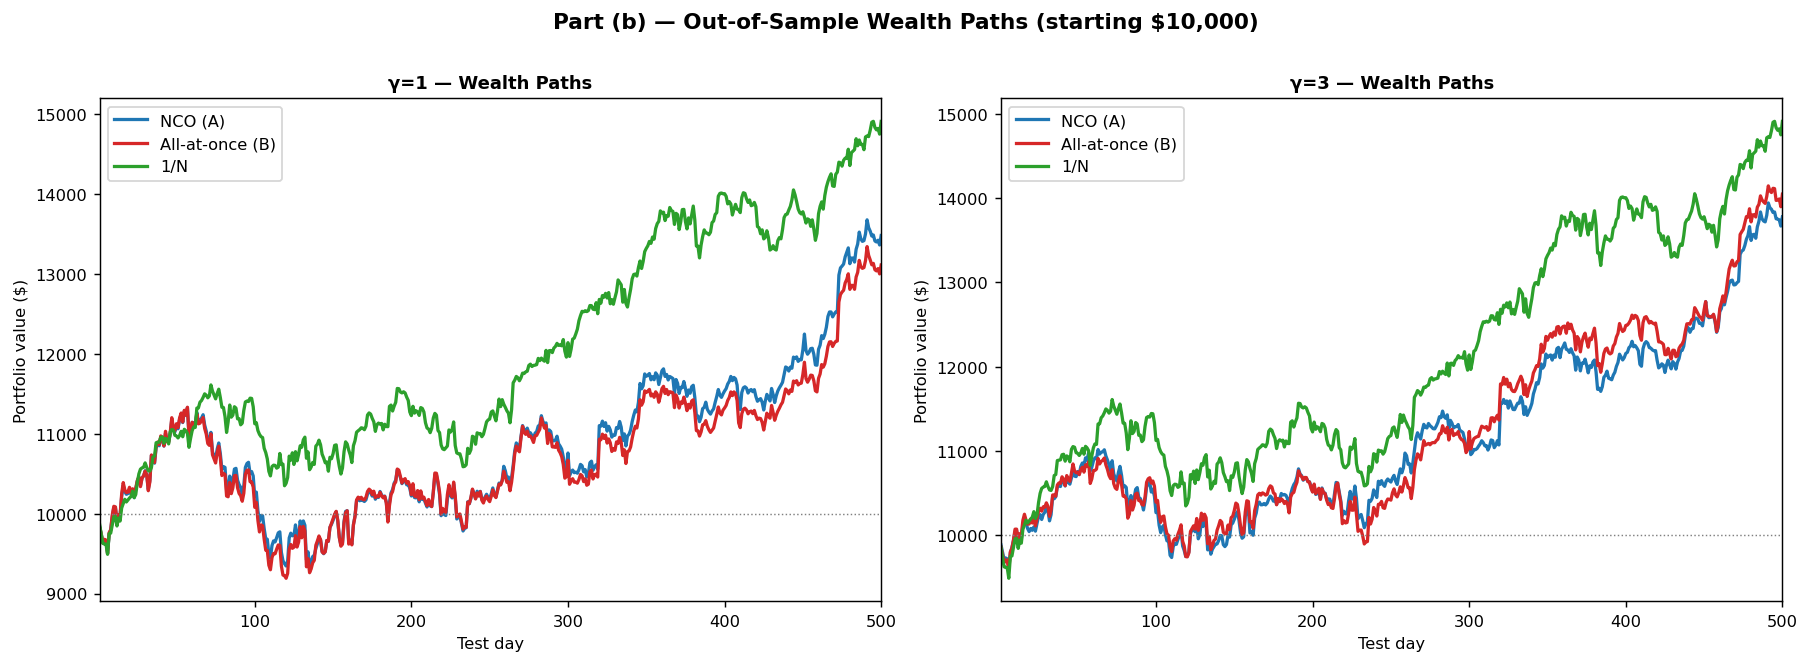

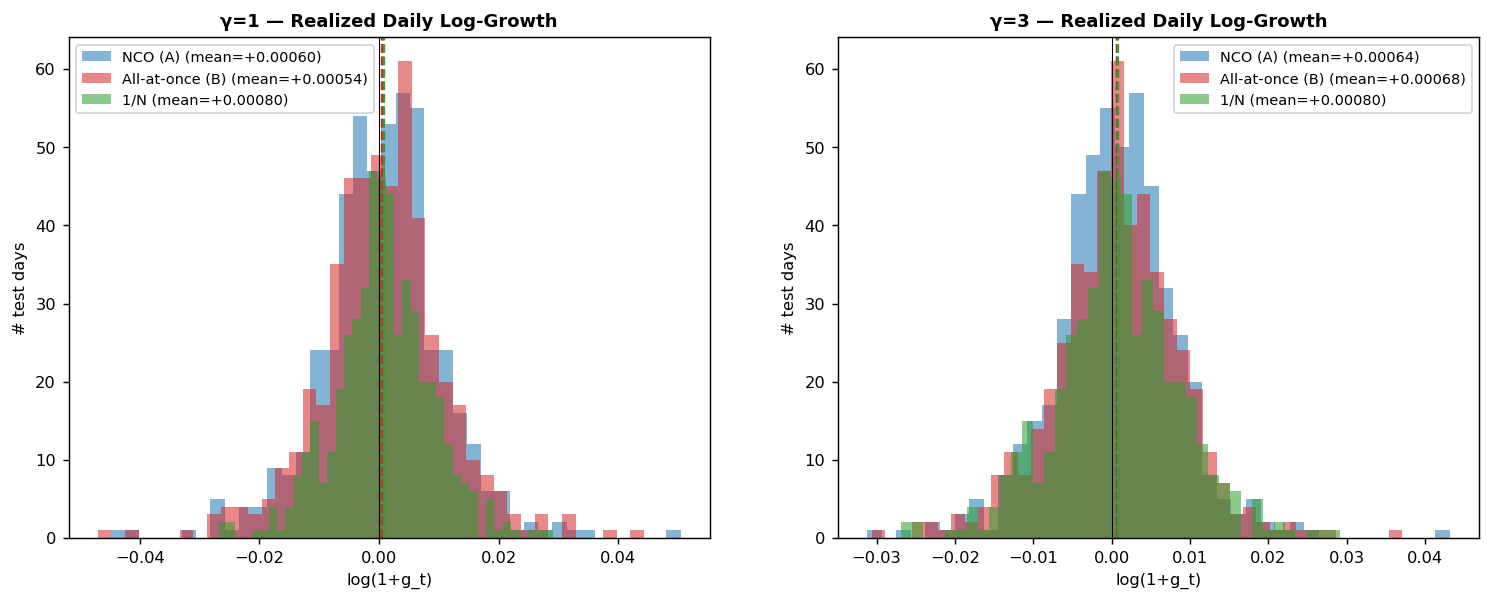

In [9]:
# ── Wealth path helper ───────────────────────────────────────────────────────
def cum_wealth(w, Rm, W0=10_000.):
    g = gross_growth(w, Rm)
    return W0 * np.cumprod(np.maximum(1. + g, EPS))

fig_w, axes_w = plt.subplots(1, 2, figsize=(14, 5))
fig_h, axes_h = plt.subplots(1, 2, figsize=(14, 5))

summary_rows = []
port_colors  = {'NCO (A)':'tab:blue', 'All-at-once (B)':'tab:red', '1/N':'tab:green'}

for gi, gamma in enumerate([1, 3]):
    r    = all_weights[gamma]
    configs = [('NCO (A)', r['w_A']), ('All-at-once (B)', r['w_B']), ('1/N', w_1N)]
    ax_w, ax_h = axes_w[gi], axes_h[gi]

    all_lg = []
    for name, w in configs:
        g_t  = gross_growth(w, R_test)
        lg_t = np.log(np.maximum(1. + g_t, EPS))
        V    = cum_wealth(w, R_test)
        eu   = realized_eu(w, R_test, gamma)
        all_lg.append(lg_t)
        color = port_colors[name]
        ax_w.plot(range(1, T_test+1), V, label=name, color=color, lw=1.8)
        ax_h.hist(lg_t, bins=40, alpha=0.55, color=color,
                  label=f'{name} (mean={lg_t.mean():+.5f})')
        ax_h.axvline(lg_t.mean(), color=color, ls='--', lw=1.3)
        summary_rows.append({'γ': gamma, 'Portfolio': name,
                              'RF share': 1-w.sum(),
                              'Final wealth ($)': V[-1],
                              'Total return': V[-1]/10_000.-1.,
                              'Mean log-growth': lg_t.mean(),
                              'Worst log-growth': lg_t.min(),
                              'Realized E[u_γ]': eu})

    ax_w.axhline(10_000, color='grey', ls=':', lw=0.8)
    ax_w.set_title(f'γ={gamma} — Wealth Paths', fontsize=10, fontweight='bold')
    ax_w.set_xlabel('Test day'); ax_w.set_ylabel('Portfolio value ($)')
    ax_w.legend(fontsize=9); ax_w.set_xlim(1, T_test)

    ax_h.axvline(0, color='k', lw=0.6)
    ax_h.set_title(f'γ={gamma} — Realized Daily Log-Growth', fontsize=10, fontweight='bold')
    ax_h.set_xlabel('log(1+g_t)'); ax_h.set_ylabel('# test days')
    ax_h.legend(fontsize=8)

fig_w.suptitle('Part (b) — Out-of-Sample Wealth Paths (starting $10,000)',
               fontsize=12, fontweight='bold', y=1.01)
fig_w.tight_layout(); plt.show()

fig_h.suptitle('Part (b) — Realized Daily Log-Growth Distributions',
               fontsize=12, fontweight='bold', y=1.01)
fig_h.tight_layout(); plt.show()


In [10]:
# ── Summary table ────────────────────────────────────────────────────────────
df_sum = (pd.DataFrame(summary_rows)
            .set_index(['γ','Portfolio'])
            .sort_index())
print("Out-of-sample summary table:")
print(df_sum.round(5).to_string())


Out-of-sample summary table:
                   RF share  Final wealth ($)  Total return  Mean log-growth  Worst log-growth  Realized E[u_γ]
γ Portfolio                                                                                                    
1 1/N               0.05000       14910.21849       0.49102          0.00080          -0.02684          0.00080
  All-at-once (B)   0.00000       13112.75204       0.31128          0.00054          -0.04703          0.00054
  NCO (A)          -0.00000       13481.87809       0.34819          0.00060          -0.04487          0.00060
3 1/N               0.05000       14910.21849       0.49102          0.00080          -0.02684          0.00073
  All-at-once (B)  -0.00000       14047.77451       0.40478          0.00068          -0.03060          0.00061
  NCO (A)           0.13056       13778.55861       0.37786          0.00064          -0.03122          0.00058


**Part (b) key findings:**

Across both γ regimes, **1/N wins the horse race** — it delivers the highest final wealth
($14,910), the best mean daily log-growth (+0.00080), and the least-bad worst day (−2.68%).
Among the optimized portfolios, NCO and all-at-once are close to each other with NCO slightly
ahead at γ=1 and slightly behind at γ=3. The CRRA-γ=3 constraint does modestly improve the
worst-day outcome for NCO relative to γ=1, at the cost of a small reduction in mean log-growth.


---
## Part (c) [8 pts] — Why the Correlation Distance?

MLdP's clustering recipe maps $\rho_{ij} \mapsto D_{ij} = \sqrt{\tfrac{1}{2}(1-\rho_{ij})}$
before feeding the result to $k$-means. Three reasons this transform is necessary.

**1. Clustering needs a true metric; correlation is not one.**
$k$-means is a distance-based algorithm: it partitions points by minimizing within-cluster
squared distances to centroids, implicitly assuming that the input space satisfies the
triangle inequality and that "smaller = more similar." Correlation is a *similarity* measure
living in $[-1,1]$, not a distance — it has the wrong direction (higher = more alike), the
wrong range (can be negative), and does not satisfy the triangle inequality. Even the simple
patch $1-\rho_{ij}$ fails the triangle inequality. $D_{ij}=\sqrt{\tfrac{1}{2}(1-\rho_{ij})}$
**is** a proper metric: $D=0 \iff \rho=1$, $D=\tfrac{1}{\sqrt{2}} \iff \rho=0$,
$D=1 \iff \rho=-1$, and it satisfies non-negativity, symmetry, and the triangle inequality.
It is in fact the Euclidean distance between unit-variance standardized return vectors, giving
it a clean geometric meaning.

**2. The sign problem: hedges and co-movers must land on opposite ends of the axis.**
Feeding raw $\rho$ to $k$-means creates a contradiction: two assets with $\rho=-0.95$
(a near-perfect hedge — economically as *different* as two assets can be) and two with
$\rho=+0.95$ (near-perfect co-movers) have the same $|\rho|$ but should end up as far apart
as possible, not equally far from zero. If you treat $\rho$ as a coordinate, a strong negative
correlation looks like it belongs in a different cluster from zero-correlation, when in fact the
more natural grouping is: *strong co-movers cluster together* (they move as a unit) and *strong
hedges are kept apart* (they diversify each other). $D$ is monotone in the right direction:
$\rho \to +1 \Rightarrow D \to 0$ (collapse to the same point), $\rho \to -1 \Rightarrow D \to 1$
(maximally separated). No sign confusion.

**3. We cluster on each asset's full distance *profile*, not on pairwise numbers.**
The feature vector passed to $k$-means for asset $i$ is its entire column
$\mathbf{d}_i = (D_{1i}, D_{2i}, \dots, D_{pi})^\top$ — its correlation-distance to
*every* asset in the universe. $k$-means then applies ordinary Euclidean distance
*between these vectors*. Two assets are judged similar when they share a *similar
pattern of co-movement with the whole universe*, not merely when they happen to be
correlated with each other. This is a richer and more noise-robust notion of co-grouping:
two assets that are both strongly correlated with a large block of the market (even if
not perfectly correlated with each other) will have similar $\mathbf{d}$ columns and will
cluster together. This global similarity measure is only meaningful once $D$ defines a valid
coordinate space — which is exactly what the metric property guarantees.


---
## Part (d) [12 pts] — Synthesis

### 1. Does NCO still beat all-at-once once shorting and borrowing are disallowed?

Looking at the summary table, NCO edges out all-at-once at γ=1 (mean log-growth +0.00060 vs
+0.00054, final wealth \$13,482 vs \$13,113), and they are essentially tied at γ=3 (all-at-once
slightly ahead: +0.00068 vs +0.00064). The margin is small and the ranking is not robust — the
two optimized portfolios perform similarly.

More revealing is *what happened to the across-cluster step of NCO.* In the lecture notebook
(unconstrained), NCO's across-cluster Kelly solve distributed capital meaningfully across
clusters, exploiting their lower within-cluster correlations to construct a diversified
meta-portfolio. Here, the across-cluster constrained optimizer places **all weight on a single
cluster (Cluster 3)** in both γ regimes. With the no-short constraint, the across-cluster
optimizer cannot exploit the hedge value of negatively or weakly correlated cluster portfolios
by going short one to lever into another; it can only go long. Faced with five cluster portfolios
that are all positively correlated, it simply picks the one it believes is best and allocates
100% there. This collapses NCO to a single-cluster problem and eliminates the diversification
benefit that made NCO powerful in the unconstrained setting. NCO's lecture-notebook edge came
from the ability to short across clusters, not from the clustering itself.

### 2. How much do the optimizers leave in the risk-free asset, and how does that change with γ?

At **γ=1** (log/Kelly), both Portfolio A and B hold essentially **0% in the risk-free asset**
— they invest their entire budget in risky assets. Log utility implies the Kelly criterion,
which under no-borrowing and a very small risk-free rate simply pushes all weight into the
highest Sharpe-ratio assets (the constraint that binds is the budget constraint, not the
no-borrowing constraint separately). The 1/N portfolio holds its fixed 5% in the risk-free.

At **γ=3**, NCO leaves **13.1% in the risk-free asset**, while all-at-once again holds
essentially 0%. The contrast is striking: greater risk aversion pulls NCO's within-cluster
solutions to leave slack (each cluster's constrained solution uses less than its full budget),
and that slack propagates through the across-cluster composition into a meaningful cash
allocation. All-at-once does not accumulate this slack — it solves a single 19-asset problem
and finds a corner solution that uses the full budget anyway. So the more risk-averse agent
*does* leave more in cash, but only for NCO; all-at-once barely responds to γ on this dimension.

### 3. Does raising γ from 1 to 3 reshuffle the ranking? The optimizers vs. 1/N.

Raising γ from 1 to 3 does not change the ranking: **1/N wins in both regimes**. On mean
log-growth, 1/N (+0.00080/day) beats NCO (+0.00060–0.00064) and all-at-once (+0.00054–0.00068)
in every scenario. On the worst day, 1/N again dominates: its worst loss is −2.68% versus −4.5%
to −4.7% for the optimized portfolios at γ=1. Raising γ to 3 narrows the worst-day gap
(NCO's worst day improves to −3.12%), but 1/N still wins.

This echoes the central finding of DeMiguel, Garlappi & Uppal (2009): even highly sophisticated
optimization routines that rely on estimated means and covariances tend to *underperform naive
equal-weighting* out of sample, because the estimation error in the inputs more than offsets
the theoretical advantage of the optimized solution. Here, the copula-and-Kelly machinery
correctly identifies stocks 3 and 14 as the strongest individual performers on the training set,
but concentrating into two stocks leaves the portfolio exposed to their specific test-period
realizations. The 1/N portfolio spreads this idiosyncratic risk uniformly across all 19 assets
plus the risk-free, and the diversification benefit overwhelms the in-sample optimality advantage.
The lesson generalizes: once realistic constraints are imposed (no shorting, no borrowing) and the
optimizer can no longer exploit the full covariance structure through both long and short positions,
the edge over naive diversification shrinks dramatically. Constraints that look like they should
*help* by preventing wild leverage often remove exactly the degrees of freedom that make
optimization worthwhile in the first place.
